# H1N1 subclade 比例预测：数据读取与时间分布图

本 notebook 只在本地使用 Pandas 读取 Nextclade TSV；不会把逐行数据发送给大模型，也不会修改原始文件。当前步骤读取必要字段、检查 `columns/head`，按 collection date 做 14-day bin，并从 2017 年开始绘制 Nextclade subclade 比例堆积图。默认遵循新版比赛口径，也可通过 `LABEL_MODE = 'legacy'` 切回旧体系。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'src' else Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT / 'src'
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.h1n1_subclade_plot import (
    DEFAULT_START_DATE,
    build_binned_tables,
    plot_subclade_area,
    read_nextclade_table,
)

INPUT_TSV = PROJECT_ROOT / 'clade注释_sorted/H1N1/h1n1_results_MW626062_sorted.tsv'
LABEL_MODE = 'nextclade'  # nextclade / legacy
OUTPUT_PNG = PROJECT_ROOT / f'outputs/h1n1_demo/h1n1_{LABEL_MODE}_subclade_proportions_from_2017.png'
START_DATE = DEFAULT_START_DATE
END_DATE = None
BIN_DAYS = 14
ENABLE_INTERACTIVE = False  # 手动交互时改为 True；批量执行保持 False

assert INPUT_TSV.exists(), f'Input file not found: {INPUT_TSV}'
INPUT_TSV

PosixPath('/Users/oliver/Desktop/Alright-strain/clade注释_sorted/H1N1/h1n1_results_MW626062_sorted.tsv')

## 1. 读取必要字段并做小规模检查

读取函数只载入 `seqName`、`legacy-clade`、`subclade` 和 `clade`。collection date 从 `seqName` 中第一个完整 ISO 日期提取。默认 `LABEL_MODE = 'nextclade'`，此时 `prediction_branch` 按 `subclade -> clade -> legacy-clade` 回退；设置为 `'legacy'` 时按 `legacy-clade -> subclade -> clade` 回退。所有字段都无有效值时记为 `Unassigned`。

In [2]:
records = read_nextclade_table(INPUT_TSV, label_mode=LABEL_MODE)
print(f'Label mode: {LABEL_MODE}')
print(f'Rows loaded: {len(records):,}')
print('Columns:', records.columns.tolist())
display(records[['collection_date', 'legacy-clade', 'subclade', 'clade', 'prediction_branch']].head())

Label mode: nextclade
Rows loaded: 165,911
Columns: ['seqName', 'clade', 'subclade', 'legacy-clade', 'collection_date', 'prediction_branch']


,collection_date,legacy-clade,subclade,clade,prediction_branch
0,2012-12-04,<NA>,<NA>,<NA>,Unassigned
1,2012-12-04,<NA>,<NA>,<NA>,Unassigned
2,2023-12-11,6B.1A.5a.2a,C.1,C.1,C.1
3,2023-12-07,6B.1A.5a.2a,C.1.9,C.1.9,C.1.9
4,2023-12-12,6B.1A.5a.2a.1,D.2,D.2,D.2


In [3]:
plot_period = records['collection_date'].ge(START_DATE)
nextclade_style = records['prediction_branch'].str.match(r'^[A-D](?:\.|$)', na=False)
summary = pd.Series({
    'rows': len(records),
    'valid_collection_dates': int(records['collection_date'].notna().sum()),
    'collection_date_min': records['collection_date'].min(),
    'collection_date_max': records['collection_date'].max(),
    'branches_including_unassigned': int(records['prediction_branch'].nunique()),
    'unassigned_rows': int(records['prediction_branch'].eq('Unassigned').sum()),
    'plot_period_rows': int(plot_period.sum()),
    'nextclade_style_rows_in_plot_period': int((plot_period & nextclade_style).sum()),
    'nextclade_style_share_in_plot_period': (plot_period & nextclade_style).sum() / plot_period.sum(),
})
display(summary.to_frame('value'))

,value
rows,165911
valid_collection_dates,165911
collection_date_min,2009-01-01 00:00:00
collection_date_max,2026-09-20 00:00:00
branches_including_unassigned,41
unassigned_rows,126
plot_period_rows,157685
nextclade_style_rows_in_plot_period,138248
nextclade_style_share_in_plot_period,0.876735


## 2. 14-day counts 与 proportions

`counts` 保留所有14天 bin，包括没有记录的空 bin；`proportions` 在非空 bin 内按该 bin 总毒株数归一化。

In [4]:
counts, proportions, bin_totals = build_binned_tables(
    records,
    bin_days=BIN_DAYS,
    start_date=START_DATE,
    end_date=END_DATE,
)
print(f'Bins: {len(counts):,}; branches: {counts.shape[1]:,}; records in plotted period: {int(bin_totals.sum()):,}')
display(counts.head())
display(proportions.head())

Bins: 254; branches: 40; records in plotted period: 157,685


prediction_branch,Unassigned,6B.1,6B.1A,6B.1A.1,6B.1A.5b,6B,6B.1A.3,6B.1A.2,6B.1A.4,6B.1A.6,...,C.1.7,C.1.6,C.1.7.1,C.1.7.2,C.1.9.2,D.3,D.4,C.1.9.1,C.1.9.4,D.3.1.1
bin_start,,,,,,,,,,,,,,,,,,,,,
2017-01-01,1,137,7,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2017-01-15,0,140,2,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2017-01-29,0,124,2,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2017-02-12,0,97,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2017-02-26,0,96,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


prediction_branch,Unassigned,6B.1,6B.1A,6B.1A.1,6B.1A.5b,6B,6B.1A.3,6B.1A.2,6B.1A.4,6B.1A.6,...,C.1.7,C.1.6,C.1.7.1,C.1.7.2,C.1.9.2,D.3,D.4,C.1.9.1,C.1.9.4,D.3.1.1
bin_start,,,,,,,,,,,,,,,,,,,,,
2017-01-01,0.006757,0.925676,0.047297,0.020270,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-15,0.000000,0.979021,0.013986,0.000000,0.006993,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-29,0.000000,0.968750,0.015625,0.015625,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-02-12,0.000000,0.979798,0.010101,0.010101,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-02-26,0.000000,0.989691,0.010309,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. 从 2017 年开始绘制并保存 Nextclade subclade 比例堆积图

画图时跳过没有任何记录的空 bin，使相邻观测点连续显示；这只影响展示，不改变 `counts` 和 `proportions` 表。

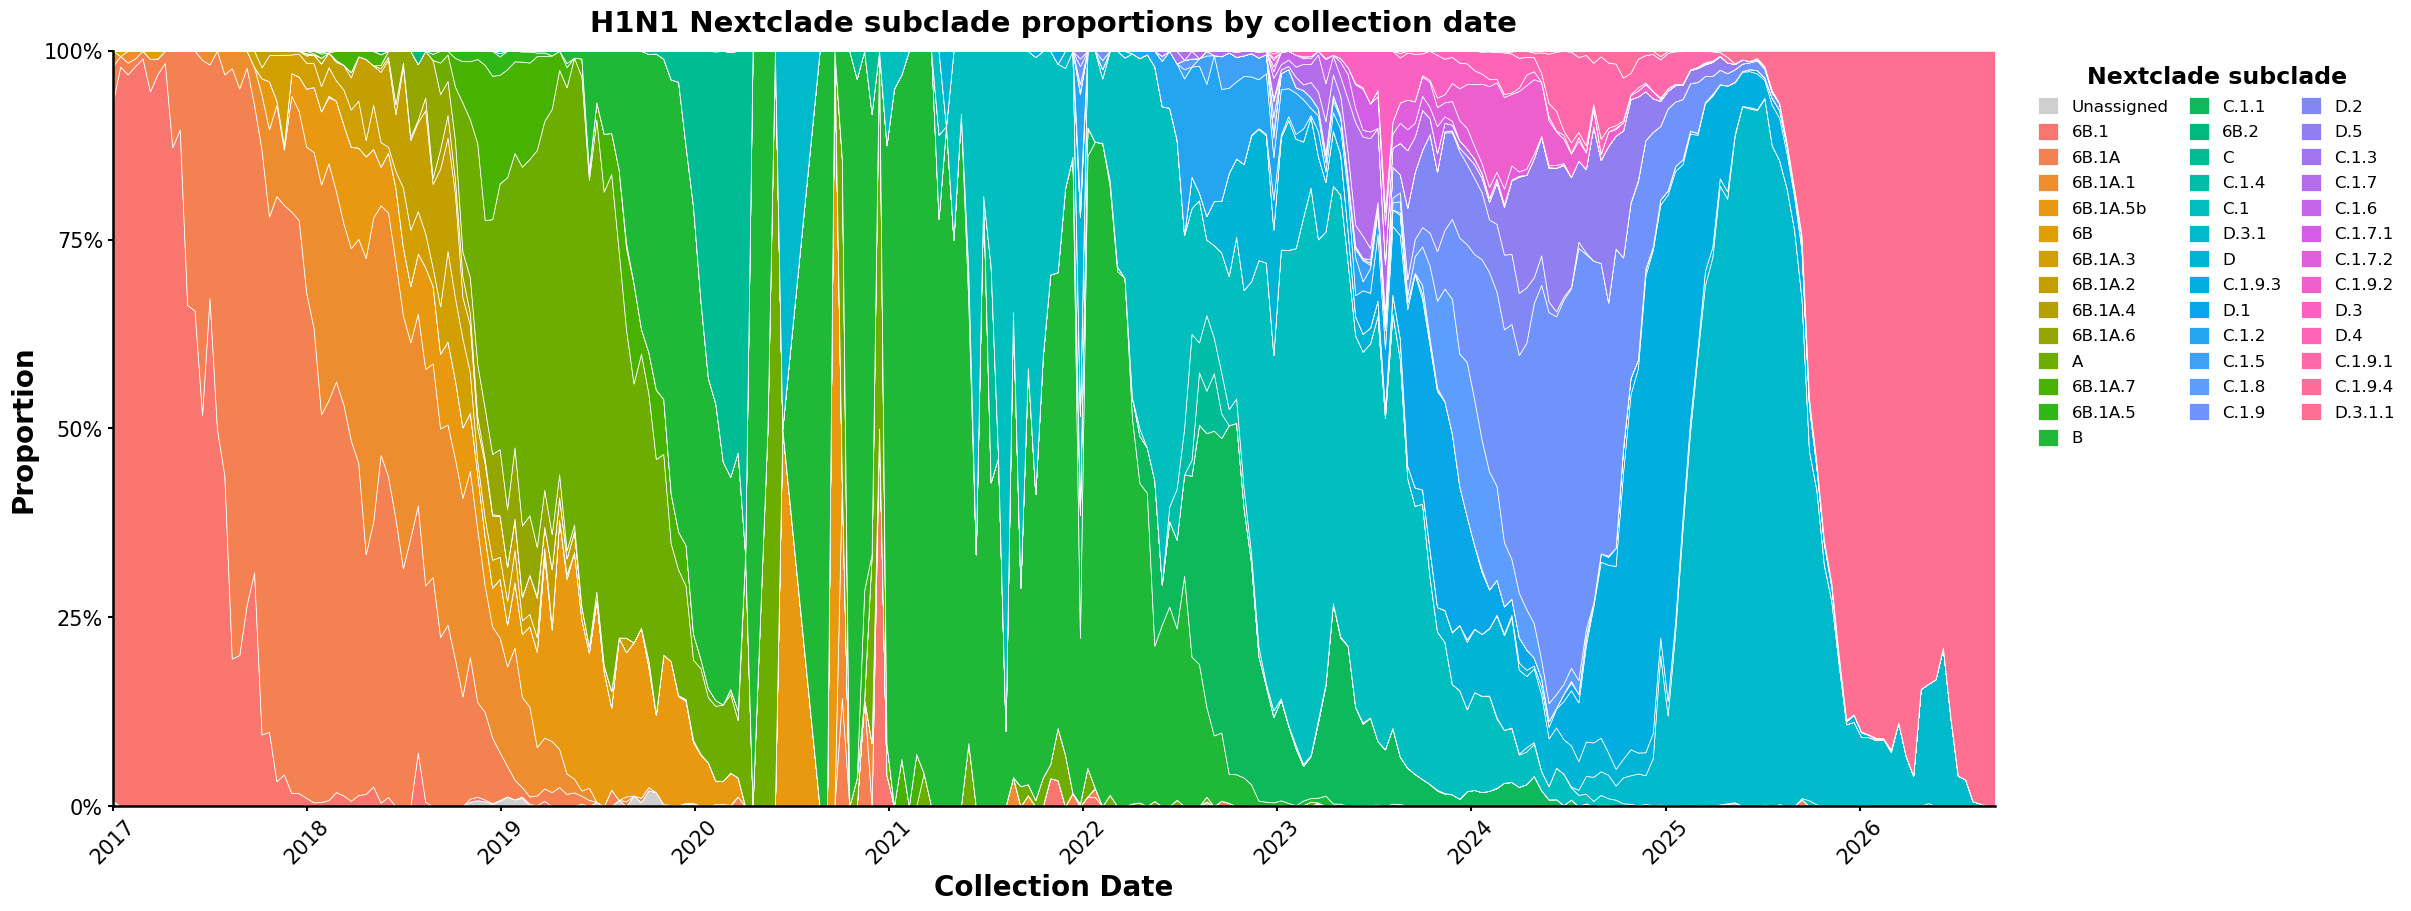

Saved to: /Users/oliver/Desktop/Alright-strain/outputs/h1n1_demo/h1n1_nextclade_subclade_proportions_from_2017.png


In [5]:
is_legacy = LABEL_MODE == 'legacy'
figure, axis = plot_subclade_area(
    proportions,
    output_path=OUTPUT_PNG,
    title=('H1N1 legacy subclade proportions by collection date' if is_legacy
           else 'H1N1 Nextclade subclade proportions by collection date'),
    legend_title='Legacy subclade' if is_legacy else 'Nextclade subclade',
)
display(figure)
plt.close(figure)
print(f'Saved to: {OUTPUT_PNG}')

## 4. 可选：交互式调整起始年份和 bin 大小

将前面的 `ENABLE_INTERACTIVE` 改为 `True` 后重新运行本单元，即可启用控件。默认关闭，以便 notebook 能在无界面的批处理环境中完整执行。

In [6]:
from ipywidgets import IntSlider, SelectionSlider, interact

def interactive_subclade_plot(start_year=2017, bin_days=14):
    _, interactive_proportions, interactive_totals = build_binned_tables(
        records,
        bin_days=bin_days,
        start_date=f'{start_year}-01-01',
    )
    fig, _ = plot_subclade_area(
        interactive_proportions,
        title=f'H1N1 {LABEL_MODE} subclade proportions ({bin_days}-day bins)',
        legend_title='Legacy subclade' if LABEL_MODE == 'legacy' else 'Nextclade subclade',
    )
    display(fig)
    plt.close(fig)
    print(f'Records shown: {int(interactive_totals.sum()):,}')

if ENABLE_INTERACTIVE:
    interact(
        interactive_subclade_plot,
        start_year=IntSlider(value=2017, min=2017, max=2025, step=1, description='Start year'),
        bin_days=SelectionSlider(options=[7, 14, 28], value=14, description='Bin days'),
    );
else:
    print('Interactive controls disabled; set ENABLE_INTERACTIVE = True to enable them.')

Interactive controls disabled; set ENABLE_INTERACTIVE = True to enable them.


## 5. 六模型 benchmark：frequency vs counts（2 × 3）

使用完全相同的 cutoff、lookback 和 holdout，对每个 B 系列方法构造两条训练路线：

| 训练输入 | B0 | B1 | B2 |
|---|---|---|---|
| Frequency | F-B0 persistence | F-B1 trend proxy | F-B2 renewal proxy |
| Counts | C-B0 count persistence | C-B1 count-weighted trend proxy | C-B2 count-weighted renewal proxy |

count 路线先预测未来 expected counts，再逐行归一化为 frequency。六个模型最终都只与 holdout counts 计算出的真实 label frequency 比较。

In [7]:
from src.h1n1_benchmarks import SIX_MODEL_LABELS, run_six_model_backtest

BACKTEST_CUTOFF = pd.Timestamp('2024-12-31')
FORECAST_HORIZON_BINS = 12  # 12 * 14 = 168 days
BENCHMARK_LOOKBACK_BINS = 26  # about one year
BENCHMARK_OUTPUT_DIR = PROJECT_ROOT / 'outputs/h1n1_demo/benchmarks'
BENCHMARK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

(
    six_frequency_predictions,
    count_model_predictions,
    benchmark_actual_counts,
    benchmark_actual_frequency,
    six_model_metrics,
) = run_six_model_backtest(
    counts,
    cutoff=BACKTEST_CUTOFF,
    horizon_bins=FORECAST_HORIZON_BINS,
    lookback_bins=BENCHMARK_LOOKBACK_BINS,
)
effective_cutoff = counts.index[counts.index <= BACKTEST_CUTOFF][-1]
print(f'Effective cutoff: {effective_cutoff.date()}')
print(f'Holdout: {benchmark_actual_counts.index.min().date()} .. {benchmark_actual_counts.index.max().date()}')
print(f'Models compared: {len(six_model_metrics)}')
display(six_model_metrics)

Effective cutoff: 2024-12-22
Holdout: 2025-01-05 .. 2025-06-08
Models compared: 6


,training_input,MAE,RMSE,mean_TVD,mean_JSD
model,,,,,
Counts · B2 renewal proxy,counts,0.017004,0.077226,0.340084,0.086390
Frequency · B0 persistence,frequency,0.022684,0.099488,0.453674,0.149838
Counts · B0 persistence,counts,0.022684,0.099488,0.453674,0.149838
Frequency · B2 renewal proxy,frequency,0.023972,0.110707,0.479434,0.167479
Frequency · B1 trend proxy,frequency,0.029181,0.117128,0.583620,0.238906
Counts · B1 trend proxy,counts,0.031081,0.142641,0.621614,0.282618


### 5.1 统一评估指标

所有指标均为越小越好。`MAE` / `RMSE` 是 branch-level frequency error；`mean_TVD` 是每个时间点两个完整频率分布的平均 total variation distance；`mean_JSD` 是平均 Jensen–Shannon divergence。

C-B0 与 F-B0 归一化后理论上相同；保留两者用于验证两条数据管线没有口径偏差。

In [8]:
metrics_path = BENCHMARK_OUTPUT_DIR / 'six_model_metrics.csv'
six_model_metrics.to_csv(metrics_path)
benchmark_actual_counts.to_csv(BENCHMARK_OUTPUT_DIR / 'actual_holdout_counts.csv')
benchmark_actual_frequency.to_csv(BENCHMARK_OUTPUT_DIR / 'actual_holdout_frequency.csv')
for model_name, prediction in six_frequency_predictions.items():
    prediction.to_csv(BENCHMARK_OUTPUT_DIR / f'{model_name.lower()}_frequency_predictions.csv')
for model_name, prediction in count_model_predictions.items():
    prediction.to_csv(BENCHMARK_OUTPUT_DIR / f'{model_name.lower()}_expected_counts.csv')

b0_pipeline_difference = (
    six_frequency_predictions['F-B0'] - six_frequency_predictions['C-B0']
).abs().to_numpy().max()
print(f'Max F-B0 vs C-B0 difference: {b0_pipeline_difference:.3g}')
print(f'Metrics saved to: {metrics_path}')

Max F-B0 vs C-B0 difference: 1.11e-16
Metrics saved to: /Users/oliver/Desktop/Alright-strain/outputs/h1n1_demo/benchmarks/six_model_metrics.csv


### 5.2 六模型预测曲线

为了保持图可读，只展示 holdout 平均占比最高的 6 个 subclades；表格评分始终使用全部 subclades。虚线是 frequency-trained，实线是 count-trained。

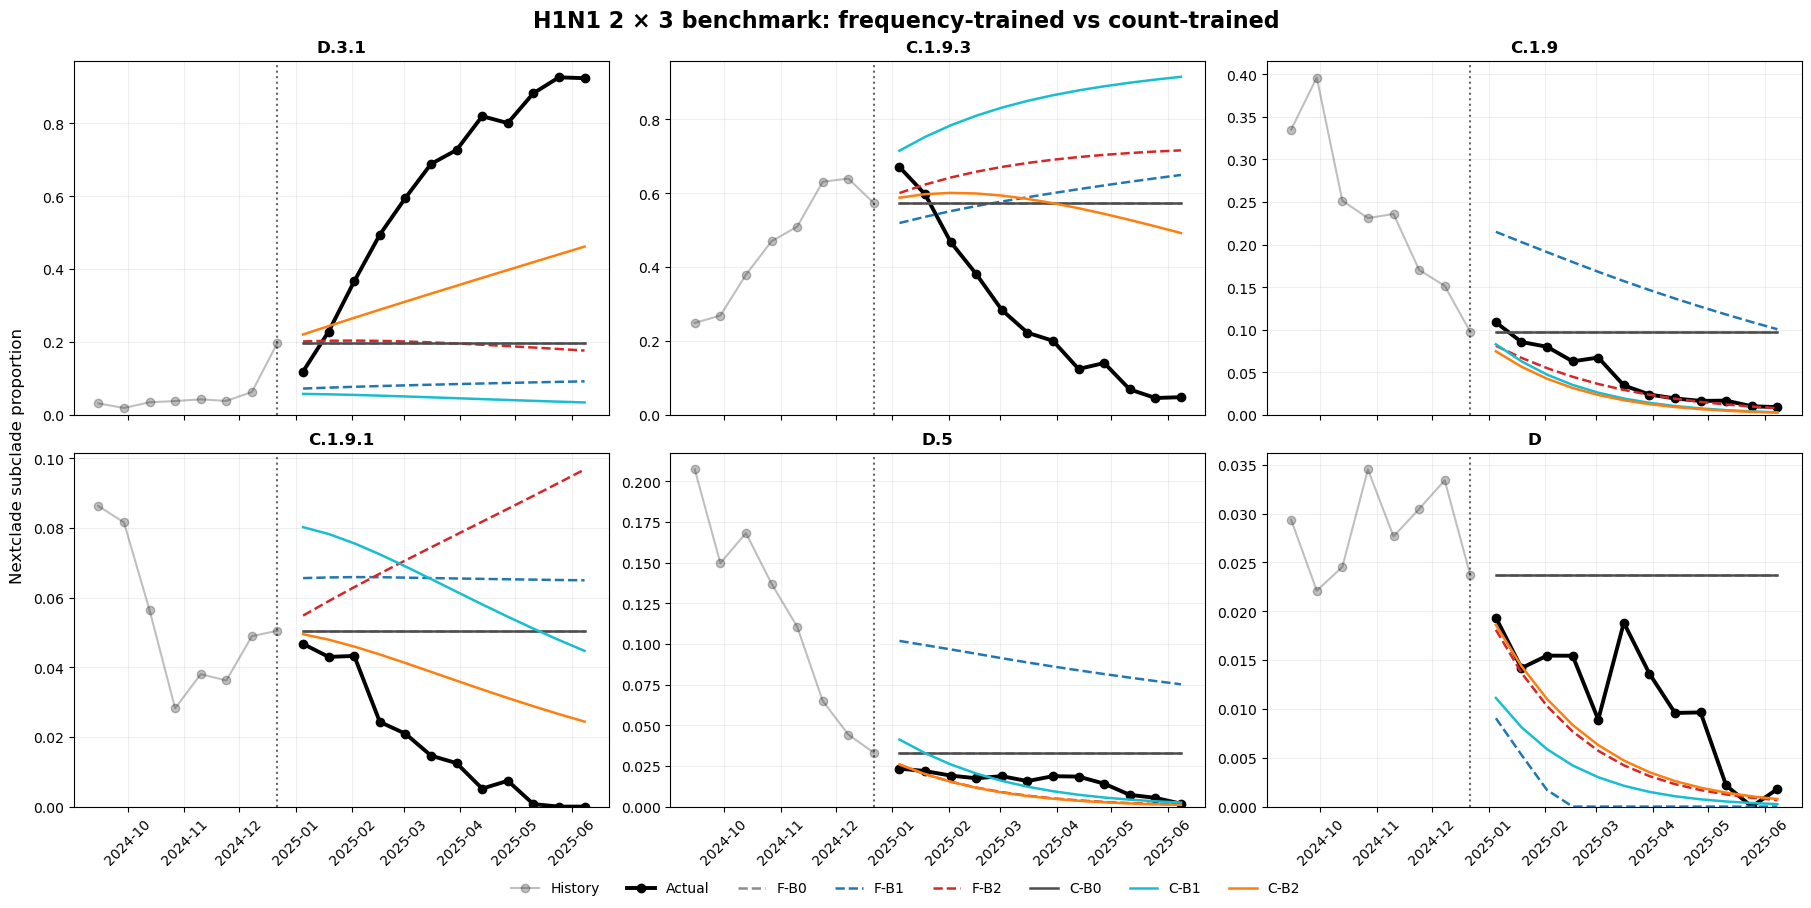

Saved to: /Users/oliver/Desktop/Alright-strain/outputs/h1n1_demo/benchmarks/six_model_backtest.png


In [9]:
top_branches = benchmark_actual_frequency.mean().nlargest(6).index.tolist()
history_for_plot = proportions.loc[:effective_cutoff].tail(8)
model_styles = {
    'F-B0': ('#8c8c8c', '--'), 'F-B1': ('#1f77b4', '--'), 'F-B2': ('#d62728', '--'),
    'C-B0': ('#4d4d4d', '-'),  'C-B1': ('#17becf', '-'),  'C-B2': ('#ff7f0e', '-'),
}
figure, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True, constrained_layout=True)

for axis, branch in zip(axes.flat, top_branches):
    axis.plot(history_for_plot.index, history_for_plot[branch], color='black', alpha=0.25, marker='o', label='History')
    axis.plot(benchmark_actual_frequency.index, benchmark_actual_frequency[branch], color='black', linewidth=2.8, marker='o', label='Actual')
    for model_name, prediction in six_frequency_predictions.items():
        color, linestyle = model_styles[model_name]
        axis.plot(prediction.index, prediction[branch], color=color, linestyle=linestyle, linewidth=1.8, label=model_name)
    axis.axvline(effective_cutoff, color='black', linestyle=':', alpha=0.6)
    axis.set_title(branch, fontweight='bold')
    axis.set_ylim(bottom=0)
    axis.grid(alpha=0.2)
    axis.tick_params(axis='x', rotation=45)

handles, labels = axes.flat[0].get_legend_handles_labels()
figure.legend(handles, labels, loc='outside lower center', ncol=8, frameon=False)
figure.suptitle('H1N1 2 × 3 benchmark: frequency-trained vs count-trained', fontweight='bold', fontsize=16)
figure.supylabel('Nextclade subclade proportion')
benchmark_figure_path = BENCHMARK_OUTPUT_DIR / 'six_model_backtest.png'
figure.savefig(benchmark_figure_path, dpi=180, bbox_inches='tight', facecolor='white')
display(figure)
plt.close(figure)
print(f'Saved to: {benchmark_figure_path}')

### 5.3 解释边界

这里的 B1/B2 两组仍然是本地 proxy，用来验证 frequency-vs-counts 的实验设计；它们不等于官方完整实现。正式复现时：

- 官方 **Nextstrain forecasts-flu MLR** 应接收同一个 cutoff 之前的 count table，并把输出适配为这里的 `C-B1` expected-count/frequency 接口。
- 官方 **RelRe** 应接收同一份 count table，再把输出适配为 `C-B2` 接口。

这样替换官方实现时，holdout、标签频率、指标和绘图完全不变，避免比较口径漂移。

## 6. 排除疫情低采样期后的 rolling-origin 回测

原计划包含 12 个日历半年窗口。由于中国在新冠疫情期间暂停或显著减少流感采样与监测，以下三个低样本窗口不进入模型排名：

- 2020-04-01–2020-09-30
- 2020-10-01–2021-03-31
- 2021-04-01–2021-09-30

主分析保留其余 9 个窗口。每个窗口的训练数据严格截止到窗口开始前一天，14-day bins 从窗口起点重新对齐，并使用 13 个完整 bins（182 天）。

In [10]:
from src.h1n1_benchmarks import (
    DEFAULT_HALF_YEAR_WINDOWS,
    build_window_aligned_counts,
    run_rolling_six_model_backtest,
)

PANDEMIC_EXCLUDED_WINDOWS = DEFAULT_HALF_YEAR_WINDOWS[-3:]
ANALYSIS_WINDOWS = DEFAULT_HALF_YEAR_WINDOWS[:-3]

excluded_rows = []
for excluded_start, excluded_end in PANDEMIC_EXCLUDED_WINDOWS:
    excluded_counts, excluded_evaluation_end, excluded_horizon = build_window_aligned_counts(
        records,
        window_start=excluded_start,
        window_end=excluded_end,
        train_start=START_DATE,
        bin_days=BIN_DAYS,
    )
    excluded_test = excluded_counts.loc[
        excluded_counts.index >= pd.Timestamp(excluded_start)
    ].iloc[:excluded_horizon]
    excluded_rows.append({
        'window_start': pd.Timestamp(excluded_start),
        'window_end': pd.Timestamp(excluded_end),
        'evaluation_end': excluded_evaluation_end,
        'nonempty_bins': int((excluded_test.sum(axis=1) > 0).sum()),
        'holdout_sequences': int(excluded_test.to_numpy().sum()),
        'reason': 'COVID-era influenza surveillance interruption',
    })
excluded_window_overview = pd.DataFrame(excluded_rows)

rolling_detail, rolling_summary = run_rolling_six_model_backtest(
    records,
    windows=ANALYSIS_WINDOWS,
    train_start=START_DATE,
    bin_days=BIN_DAYS,
    lookback_bins=BENCHMARK_LOOKBACK_BINS,
)

window_overview = (
    rolling_detail[[
        'window_number', 'window_start', 'requested_window_end',
        'evaluation_end', 'horizon_bins', 'holdout_sequences',
    ]]
    .drop_duplicates()
    .sort_values('window_number')
)
print('Excluded COVID-era low-sampling windows:')
display(excluded_window_overview)
print('Included analysis windows:')
display(window_overview)
display(rolling_summary)

Excluded COVID-era low-sampling windows:


,window_start,window_end,evaluation_end,nonempty_bins,holdout_sequences,reason
0,2021-04-01,2021-09-30,2021-09-29,13,372,COVID-era influenza surveillance interruption
1,2020-10-01,2021-03-31,2021-03-31,13,239,COVID-era influenza surveillance interruption
2,2020-04-01,2020-09-30,2020-09-29,7,29,COVID-era influenza surveillance interruption


Included analysis windows:


,window_number,window_start,requested_window_end,evaluation_end,horizon_bins,holdout_sequences
0,1,2025-10-01,2026-03-31,2026-03-31,13,13650
6,2,2025-04-01,2025-09-30,2025-09-29,13,13675
12,3,2024-10-01,2025-03-31,2025-03-31,13,31254
18,4,2024-04-01,2024-09-30,2024-09-29,13,9317
24,5,2023-10-01,2024-03-31,2024-03-30,13,26582
30,6,2023-04-01,2023-09-30,2023-09-29,13,7172
36,7,2022-10-01,2023-03-31,2023-03-31,13,14134
42,8,2022-04-01,2022-09-30,2022-09-29,13,2117
48,9,2021-10-01,2022-03-31,2022-03-31,13,1459


,rank,model_id,model,training_input,windows,mean_MAE,mean_RMSE,mean_TVD,std_TVD,mean_JSD,mean_top1_accuracy,window_wins
0,1,C-B2,Counts · B2 renewal proxy,counts,9,0.019537,0.066552,0.353857,0.147506,0.128986,0.589744,2
1,2,F-B0,Frequency · B0 persistence,frequency,9,0.021385,0.069384,0.391409,0.115898,0.137356,0.487179,4
2,3,C-B0,Counts · B0 persistence,counts,9,0.021385,0.069384,0.391409,0.115898,0.137356,0.487179,4
3,4,F-B2,Frequency · B2 renewal proxy,frequency,9,0.021414,0.076563,0.393310,0.190333,0.160751,0.581197,3
4,5,F-B1,Frequency · B1 trend proxy,frequency,9,0.027560,0.091585,0.504242,0.108227,0.191394,0.307692,0
5,6,C-B1,Counts · B1 trend proxy,counts,9,0.030194,0.104791,0.550303,0.138458,0.244892,0.341880,0


### 6.1 汇总与逐窗口结果

汇总表对保留的 9 个窗口等权平均，避免大样本窗口完全支配结果。`window_wins` 对并列第一的模型同时计一次胜出。被排除窗口单独导出作为审计记录，但不参与任何排名或均值。

In [11]:
rolling_detail_path = BENCHMARK_OUTPUT_DIR / 'rolling_9_windows_detail.csv'
rolling_summary_path = BENCHMARK_OUTPUT_DIR / 'rolling_9_windows_summary.csv'
rolling_windows_path = BENCHMARK_OUTPUT_DIR / 'rolling_9_windows_overview.csv'
excluded_windows_path = BENCHMARK_OUTPUT_DIR / 'excluded_covid_sampling_windows.csv'
rolling_detail.to_csv(rolling_detail_path, index=False)
rolling_summary.to_csv(rolling_summary_path, index=False)
window_overview.to_csv(rolling_windows_path, index=False)
excluded_window_overview.to_csv(excluded_windows_path, index=False)
print(f'Detail saved to: {rolling_detail_path}')
print(f'Summary saved to: {rolling_summary_path}')
print(f'Exclusion audit saved to: {excluded_windows_path}')

Detail saved to: /Users/oliver/Desktop/Alright-strain/outputs/h1n1_demo/benchmarks/rolling_9_windows_detail.csv
Summary saved to: /Users/oliver/Desktop/Alright-strain/outputs/h1n1_demo/benchmarks/rolling_9_windows_summary.csv
Exclusion audit saved to: /Users/oliver/Desktop/Alright-strain/outputs/h1n1_demo/benchmarks/excluded_covid_sampling_windows.csv


### 6.2 稳定性可视化

左图展示每个模型在 9 个保留窗口中的 TVD；右图展示 9 窗口的平均 TVD 和窗口间标准差。

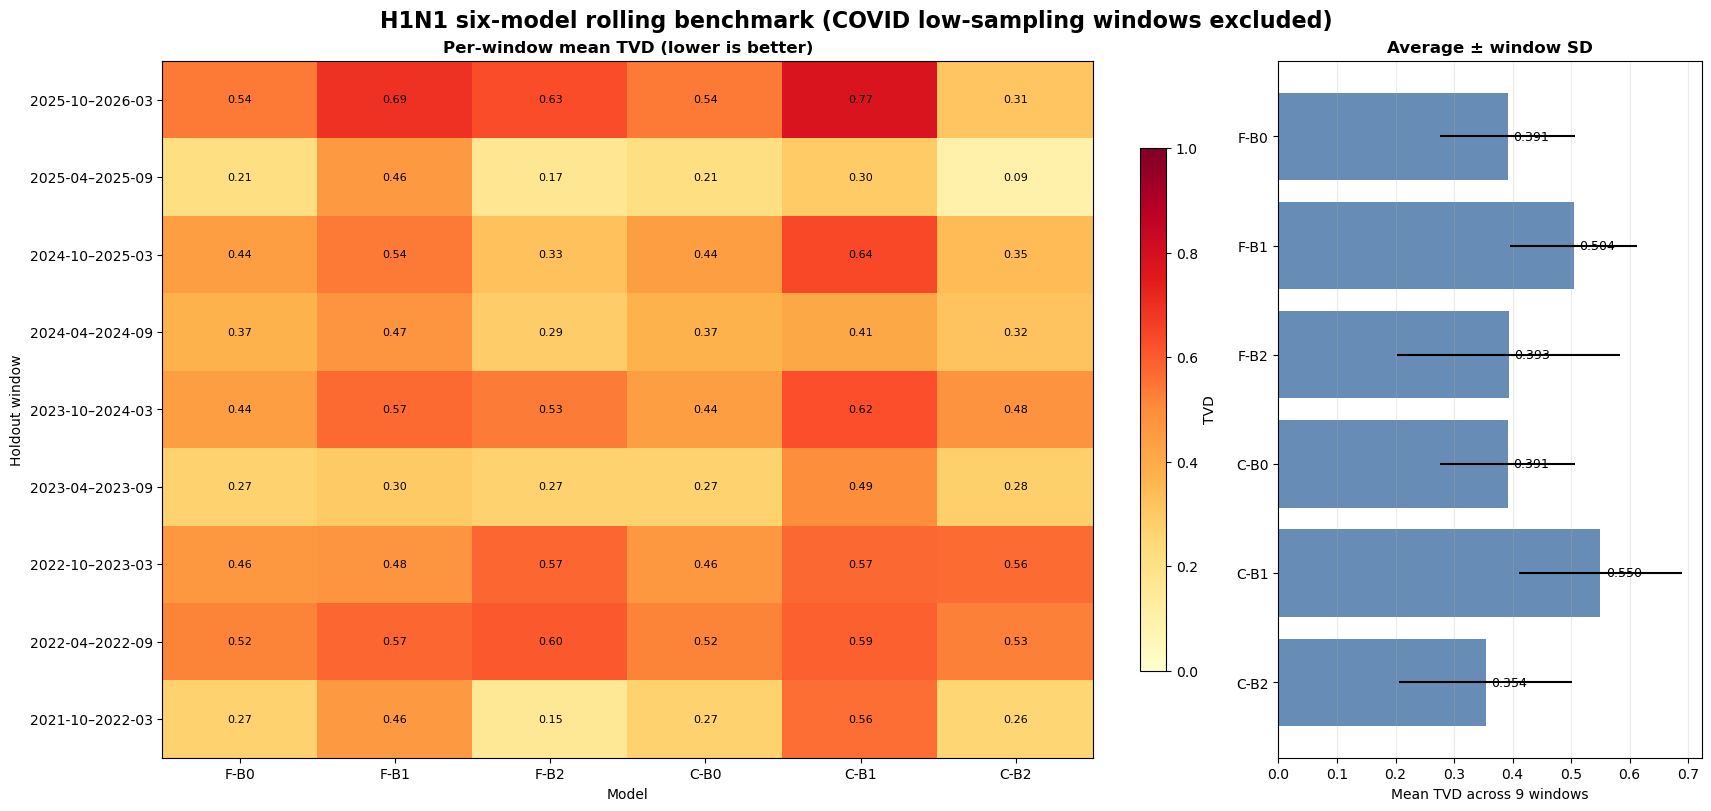

Saved to: /Users/oliver/Desktop/Alright-strain/outputs/h1n1_demo/benchmarks/rolling_9_windows_tvd.png


In [12]:
model_order = ['F-B0', 'F-B1', 'F-B2', 'C-B0', 'C-B1', 'C-B2']
window_labels = [
    f"{row.window_start:%Y-%m}–{row.requested_window_end:%Y-%m}"
    for row in window_overview.itertuples()
]
tvd_matrix = (
    rolling_detail.pivot(index='window_number', columns='model_id', values='mean_TVD')
    .reindex(index=window_overview['window_number'], columns=model_order)
)

figure, (heat_axis, summary_axis) = plt.subplots(
    1, 2, figsize=(17, 8), gridspec_kw={'width_ratios': [2.2, 1]}, constrained_layout=True
)
image = heat_axis.imshow(tvd_matrix.to_numpy(), aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
heat_axis.set_xticks(range(len(model_order)), model_order)
heat_axis.set_yticks(range(len(window_labels)), window_labels)
heat_axis.set_xlabel('Model')
heat_axis.set_ylabel('Holdout window')
heat_axis.set_title('Per-window mean TVD (lower is better)', fontweight='bold')
for row_number in range(tvd_matrix.shape[0]):
    for column_number in range(tvd_matrix.shape[1]):
        value = tvd_matrix.iat[row_number, column_number]
        heat_axis.text(column_number, row_number, f'{value:.2f}', ha='center', va='center', fontsize=8)
figure.colorbar(image, ax=heat_axis, shrink=0.75, label='TVD')

summary_plot = rolling_summary.set_index('model_id').reindex(model_order)
positions = range(len(model_order))
summary_axis.barh(positions, summary_plot['mean_TVD'], xerr=summary_plot['std_TVD'], color='#4c78a8', alpha=0.85)
summary_axis.set_yticks(positions, model_order)
summary_axis.invert_yaxis()
summary_axis.set_xlabel('Mean TVD across 9 windows')
summary_axis.set_title('Average ± window SD', fontweight='bold')
summary_axis.grid(axis='x', alpha=0.25)
for position, value in enumerate(summary_plot['mean_TVD']):
    summary_axis.text(value + 0.01, position, f'{value:.3f}', va='center', fontsize=9)

figure.suptitle('H1N1 six-model rolling benchmark (COVID low-sampling windows excluded)', fontweight='bold', fontsize=16)
rolling_figure_path = BENCHMARK_OUTPUT_DIR / 'rolling_9_windows_tvd.png'
figure.savefig(rolling_figure_path, dpi=180, bbox_inches='tight', facecolor='white')
display(figure)
plt.close(figure)
print(f'Saved to: {rolling_figure_path}')